# Machine Learning & Time Series Pipeline
**Project:** Tesla Production & Deliveries Analysis (2015-2025)

**Objective:** To implement a complete ML Lifecycle including EDA, Feature Engineering, Regularized Regression (Ridge/Lasso), Hyperparameter Tuning, and Time Series Forecasting (ARIMA).

**Steps Covered:**
1. Data Gathering & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering (Scaling, Lag Features, Rolling Statistics)
4. Chronological Train-Test Split (Data Leakage Prevention)
5. Classical ML Models (Linear, Ridge L2, Lasso L1)
6. Hyperparameter Tuning (GridSearchCV)
7. Time Series Stationarity Check (ADF Test)
8. Forecasting

### Step 1: Importing Libraries


In [11]:
# 1. Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML and Preprocessing
from sklearn.model_selection import train_test_split,GridSearchCV,TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf


Libraries Imported Successfully!


### Step 2: Data Gathering, Preprocessing & Cleaning
First, we load the data. Since this is a time-series problem, the index must be the 'Date'.

**What we doing here:** We read the CSV file, combine the Month and Year into one 'Date' column, and drop the NaN (missing) values.

**Why we doing this:** For time series forecasting, the index must be a proper Date. Also, ML models use math calculations. If any cell is empty (NaN), the model will throw error. So we drop them to make data clean.

In [22]:
# importing the file
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

# making a date column by joining year and month
df['Date']=pd.to_datetime(df['Year'].astype(str)+'-'+df['Month'].astype(str)+'-01')
df.set_index('Date',inplace=True)
df.sort_index(inplace=True)

# checking if any value is missing
print("Missing Values:\n",df.isnull().sum())

# removing missing values if found
df=df.dropna()
df.head()

Missing Values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
Date,,,,,,,,,,,,
2015-01-01,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390
2015-01-01,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925
2015-01-01,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923
2015-01-01,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170
2015-01-01,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626


### Step 3: Exploratory Data Analysis (EDA)
**What we doing here:** We make three graphs: Line plot for trend, Boxplot for outliers, and KDE for data distribution.

**Why we doing this:** We need to understand our data before training model. Line plot show us the trend. Boxplot show us that there are some extreme Outliers in production. Because of this boxplot, we decided to use 'RobustScaler' in next steps.

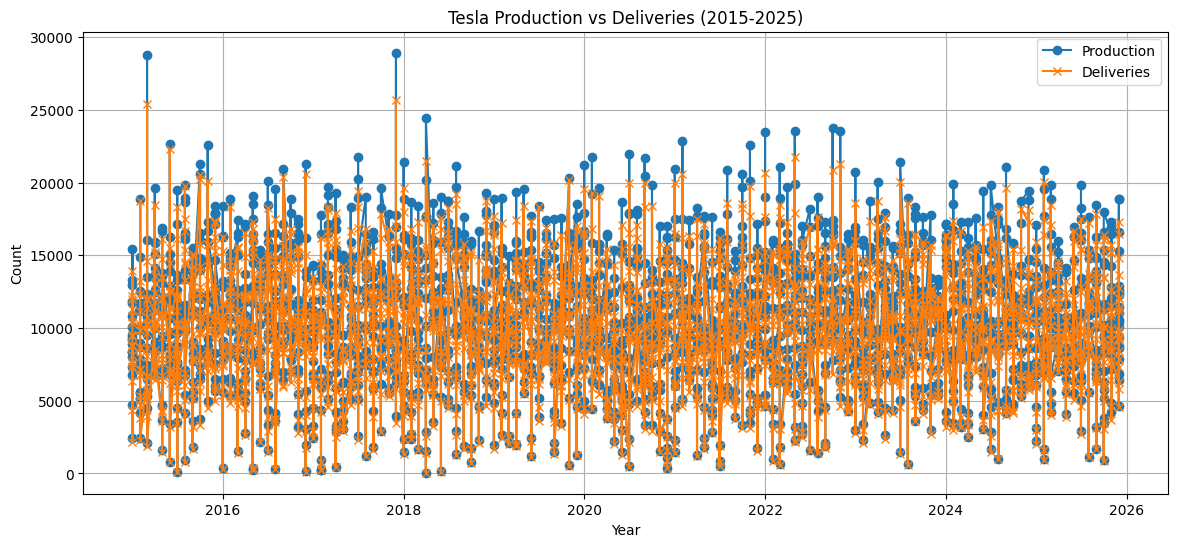

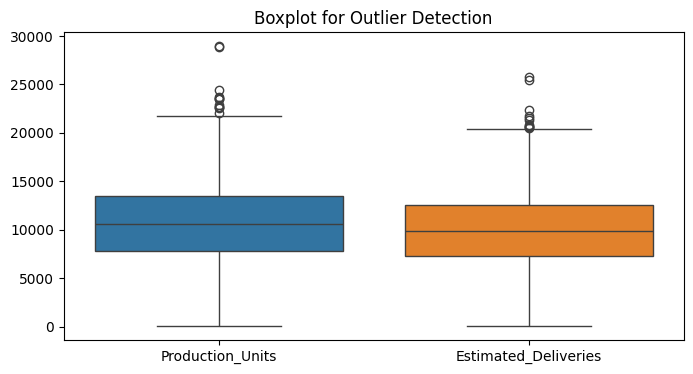

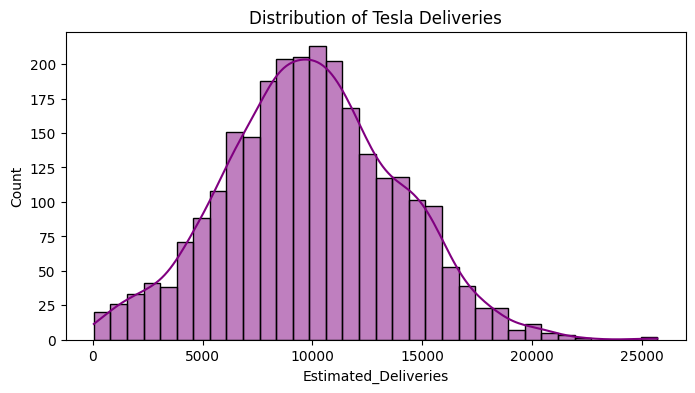

In [36]:
# plotting production and deliveries over time
plt.figure(figsize=(14,6))

plt.plot(df.index,df['Production_Units'],label='Production',marker='o')
plt.plot(df.index,df['Estimated_Deliveries'],label='Deliveries',marker='x')

plt.title('Tesla Production vs Deliveries (2015-2025)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

# checking outliers using boxplot
plt.figure(figsize=(8,4))

sns.boxplot(data=df[['Production_Units','Estimated_Deliveries']])

plt.title('Boxplot for Outlier Detection')
plt.show()

# looking at delivery distribution
plt.figure(figsize=(8,4))

sns.histplot(df['Estimated_Deliveries'],kde=True,color='purple')

plt.title('Distribution of Tesla Deliveries')
plt.show()

### Conclusion from EDA Graphs:
From this above graphs, we can understanding 3 main things:
1. **Line Graph:** The production and deliveries are going up and down together. They have very strong positive relation.
2. **Boxplot:** We can seeing some small dots outside the main box in both production and delivery. This mean our data have some "Outliers" (extreme sudden changes). Because of this, normal scaling will fail, so we decided to use `RobustScaler` in next step which is good for outliers.
3. **Distribution Plot:** The purple graph show that most of the time, Tesla deliver between 5000 to 15000 cars in a quarter. The data is slightly right skewed.

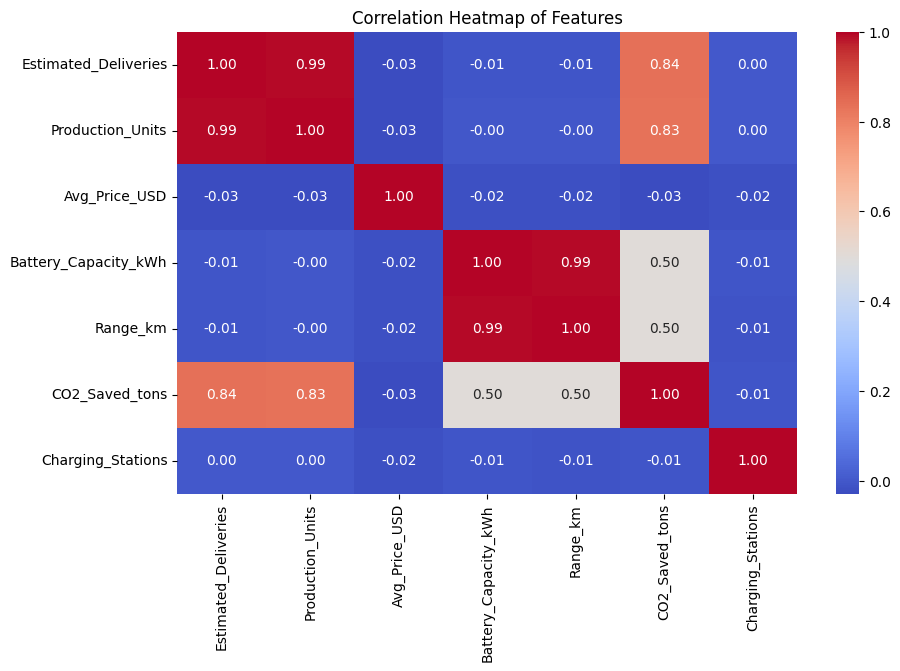

In [37]:
plt.figure(figsize=(10,6))

# selecting only numeric columns
num_cols=['Estimated_Deliveries','Production_Units','Avg_Price_USD',
          'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']

# creating correlation heatmap
sns.heatmap(df[num_cols].corr(),annot=True,fmt=".2f",cmap="coolwarm")

plt.title('Correlation Heatmap of Features')
plt.show()

Correlation Heatmap:
From this heatmap graph, we can seeing the relationship between all numerical columns.
* The dark red color mean very strong relation. We can see `Estimated_Deliveries` and `Production_Units` have 0.99 correlation. This is very logical because if production increase, delivery will also definitely increase.
* The blue color mean no relation. Things like 'Battery Capacity' and 'Price' are showing negative or zero correlation with deliveries. It mean car price is not directly affecting the delivery counts in this dataset.

### Step 4: Feature Engineering

**What we doing here:** We creating 'Lag Features' by shifting data by 1 step, and creating 'Rolling Mean' of 3 months.

**Why we doing this:** Normal regression models don't have memory of the past. Lag features give them memory so they know previous production to predict future good. Rolling mean remove the noise and give smooth trend.

In [25]:
# creating previous month values
df['Lag_1_Production']=df['Production_Units'].shift(1)
df['Lag_1_Deliveries']=df['Estimated_Deliveries'].shift(1)

# creating rolling average to catch trend
df['Rolling_Mean_3_Del']=df['Estimated_Deliveries'].rolling(window=3).mean()

# removing empty rows created after feature making
df.dropna(inplace=True)

print("Features Created Successfully. Data Shape:",df.shape)
df.head()

Features Created Successfully. Data Shape: (2638, 15)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Lag_1_Production,Lag_1_Deliveries,Rolling_Mean_3_Del
Date,,,,,,,,,,,,,,,
2015-01-01,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,12752.0,11446.0,10898.333333
2015-01-01,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,9344.0,8803.0,8872.000000
2015-01-01,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,6802.0,6367.0,7988.333333
2015-01-01,2015,1,Europe,Cybertruck,2161,2465,112637.91,120,695,225.28,Estimated (Region),14062,9165.0,8795.0,5774.333333
2015-01-01,2015,1,North America,Model S,11986,13302,91906.09,82,457,821.64,Estimated (Region),4871,2465.0,2161.0,7647.333333


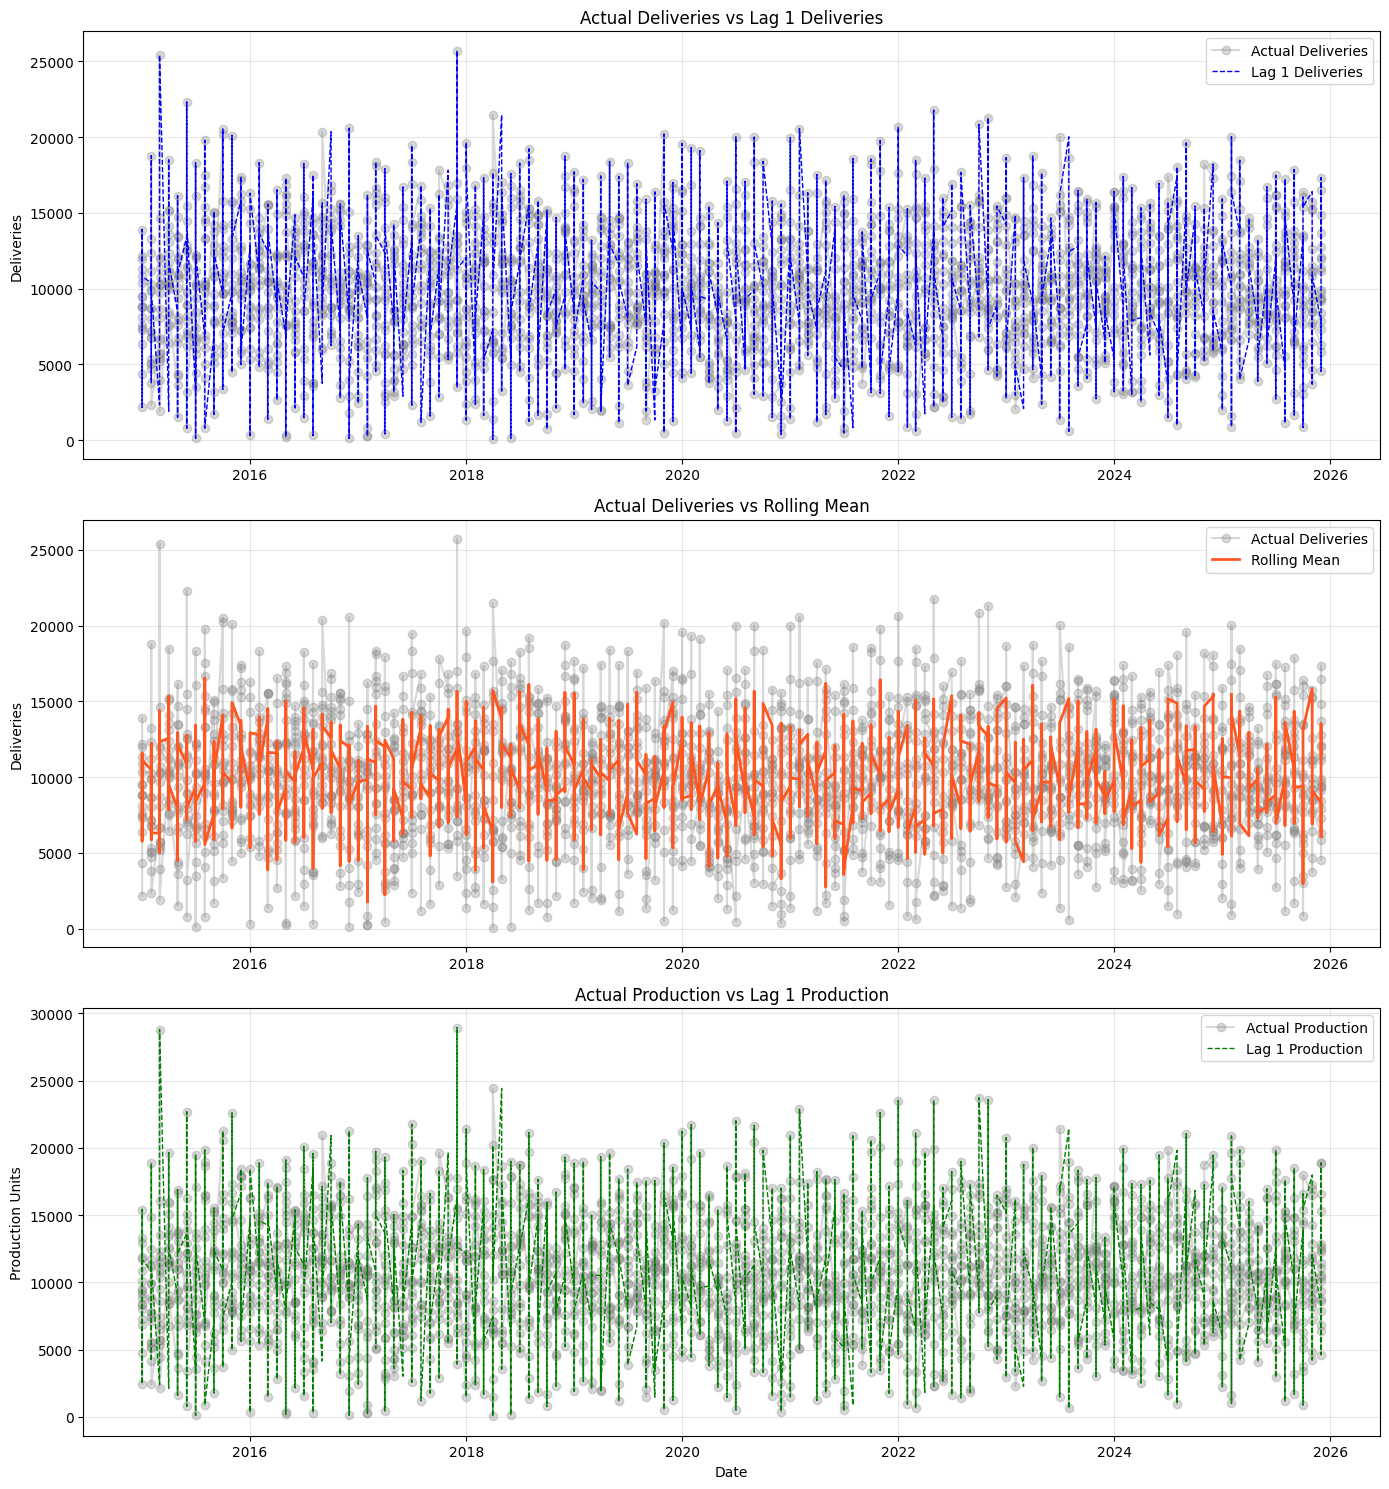

In [26]:
import matplotlib.pyplot as plt

# checking if feature columns are present
if 'Lag_1_Deliveries' in df.columns and 'Rolling_Mean_3_Del' in df.columns:

    # plotting all engineered features
    fig,axes=plt.subplots(3,1,figsize=(14,15))

    # deliveries and lag deliveries
    axes[0].plot(df.index,df['Estimated_Deliveries'],label='Actual Deliveries',color='gray',marker='o',alpha=0.3)
    axes[0].plot(df.index,df['Lag_1_Deliveries'],label='Lag 1 Deliveries',color='blue',linestyle='--',linewidth=1)
    axes[0].set_title('Actual Deliveries vs Lag 1 Deliveries')
    axes[0].set_ylabel('Deliveries')
    axes[0].legend()
    axes[0].grid(True,alpha=0.3)

    # deliveries and rolling mean
    axes[1].plot(df.index,df['Estimated_Deliveries'],label='Actual Deliveries',color='gray',marker='o',alpha=0.3)
    axes[1].plot(df.index,df['Rolling_Mean_3_Del'],label='Rolling Mean',color='#FF5722',linewidth=2)
    axes[1].set_title('Actual Deliveries vs Rolling Mean')
    axes[1].set_ylabel('Deliveries')
    axes[1].legend()
    axes[1].grid(True,alpha=0.3)

    # production and lag production
    axes[2].plot(df.index,df['Production_Units'],label='Actual Production',color='gray',marker='o',alpha=0.3)
    axes[2].plot(df.index,df['Lag_1_Production'],label='Lag 1 Production',color='green',linestyle='--',linewidth=1)
    axes[2].set_title('Actual Production vs Lag 1 Production')
    axes[2].set_ylabel('Production Units')
    axes[2].set_xlabel('Date')
    axes[2].legend()
    axes[2].grid(True,alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("Error: Lag or Rolling features not found in DataFrame. Please run Step 4 first.")

### Conclusion from Feature Engineering:
1. **Lag Graph:** In first graph, we see the blue line is shifted by 1 step. This is very helpful because it give our model "Memory" so it can look at past month to predict the next month.
2. **Rolling Mean Graph:** The grey line is actual data which is very zig-zag and noisy. It make the model confuse. But the orange line (Rolling Mean) is very smooth. It show the real hidden trend of the company growth without the small noise.

### Step 5: Data Splitting and Scaling

**What we doing here:** We split data into 80% train and 20% test sequentially without shuffling. Then we apply RobustScaler.

**Why we doing this:** We do not shuffle data because in Time Series, future data cannot predict past data (it cause Data Leakage). We use RobustScaler instead of StandardScaler because it handle the outliers we found in our EDA boxplot.

In [16]:
from sklearn.preprocessing import RobustScaler

# defining features and target
X=df.drop(['Estimated_Deliveries'],axis=1)
y=df['Estimated_Deliveries']

# splitting data in time order
split_idx=int(len(df)*0.8)
X_train,X_test=X.iloc[:split_idx],X.iloc[split_idx:]
y_train,y_test=y.iloc[:split_idx],y.iloc[split_idx:]

# finding categorical columns
categorical_cols=X.select_dtypes(include=['object']).columns

# converting categorical values into numeric
X_train=pd.get_dummies(X_train,columns=categorical_cols,drop_first=True)
X_test=pd.get_dummies(X_test,columns=categorical_cols,drop_first=True)

# making sure both datasets have same columns
X_train,X_test=X_train.align(X_test,join='left',axis=1,fill_value=0)

# scaling data to reduce effect of outliers
scaler=RobustScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print(f"Training Data: {X_train_scaled.shape}, Testing Data: {X_test_scaled.shape}")

Training Data: (2110, 20), Testing Data: (528, 20)


In [30]:
X_train_scaled

array([[-1.        , -0.83333333, -0.21166739, ...,  0.        ,
         1.        ,  0.        ],
       [-1.        , -0.83333333, -0.65433174, ...,  0.        ,
         0.        ,  0.        ],
       [-1.        , -0.83333333, -0.24283848, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.        ,  0.66666667,  0.10544188, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.        ,  0.66666667,  1.2305616 , ...,  1.        ,
         0.        ,  1.        ],
       [ 1.        ,  0.66666667,  0.2754027 , ...,  0.        ,
         1.        ,  0.        ]])

In [28]:
X_test_scaled

array([[ 1.        ,  0.66666667, -0.11710927, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.        ,  0.66666667,  0.14915107, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.        ,  0.66666667, -0.8127993 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.5       ,  1.        ,  0.82690466, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.5       ,  1.        ,  0.15211145, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.5       ,  1.        , -0.03003918, ...,  0.        ,
         1.        ,  0.        ]])

### Step 6: Model Training & Regularization

**What we doing here:** We train a normal Linear Regression, and also train Ridge (L2) and Lasso (L1) models using GridSearchCV.

**Why we doing this:** Simple Linear Regression can overfit the data easily. To fix the Bias-Variance tradeoff, we use Ridge and Lasso. They add a penalty to the model so it perform stable on new unseen data.

In [31]:
# using time series split for tuning
tscv=TimeSeriesSplit(n_splits=3)

# linear regression model
lr=LinearRegression().fit(X_train_scaled,y_train)
lr_pred=lr.predict(X_test_scaled)

# ridge model with grid search
ridge_grid=GridSearchCV(Ridge(),{'alpha':[0.1,1.0,10.0,100.0]},cv=tscv)
ridge_grid.fit(X_train_scaled,y_train)

best_ridge=ridge_grid.best_estimator_
ridge_pred=best_ridge.predict(X_test_scaled)

# lasso model with grid search
lasso_grid=GridSearchCV(Lasso(max_iter=10000),{'alpha':[0.1,1.0,10.0,100.0]},cv=tscv)
lasso_grid.fit(X_train_scaled,y_train)

best_lasso=lasso_grid.best_estimator_
lasso_pred=best_lasso.predict(X_test_scaled)

print(f"Best Ridge Alpha selected: {ridge_grid.best_params_['alpha']}")
print(f"Best Lasso Alpha selected: {lasso_grid.best_params_['alpha']}")

Best Ridge Alpha selected: 1.0
Best Lasso Alpha selected: 10.0


### Step 7: Model Evaluation Metrics

**What we doing here:** We calculate MAE, MSE, RMSE and R2 Score for all three models and plot them on bar graphs to compare.

**Why we doing this:** We want to see which model make less mistakes. RMSE tell us the error amount, and R2 Score tell us the accuracy of model. Graphs make it easy to show the result to faculty.

****MODEL EVALUATION METRICS****
            Model    MAE       MSE   RMSE  R2 Score  Adj R2
Linear Regression 322.38 153455.72 391.73    0.9885  0.9880
       Ridge (L2) 321.79 153263.24 391.49    0.9885  0.9880
       Lasso (L1) 323.90 155582.38 394.44    0.9883  0.9878


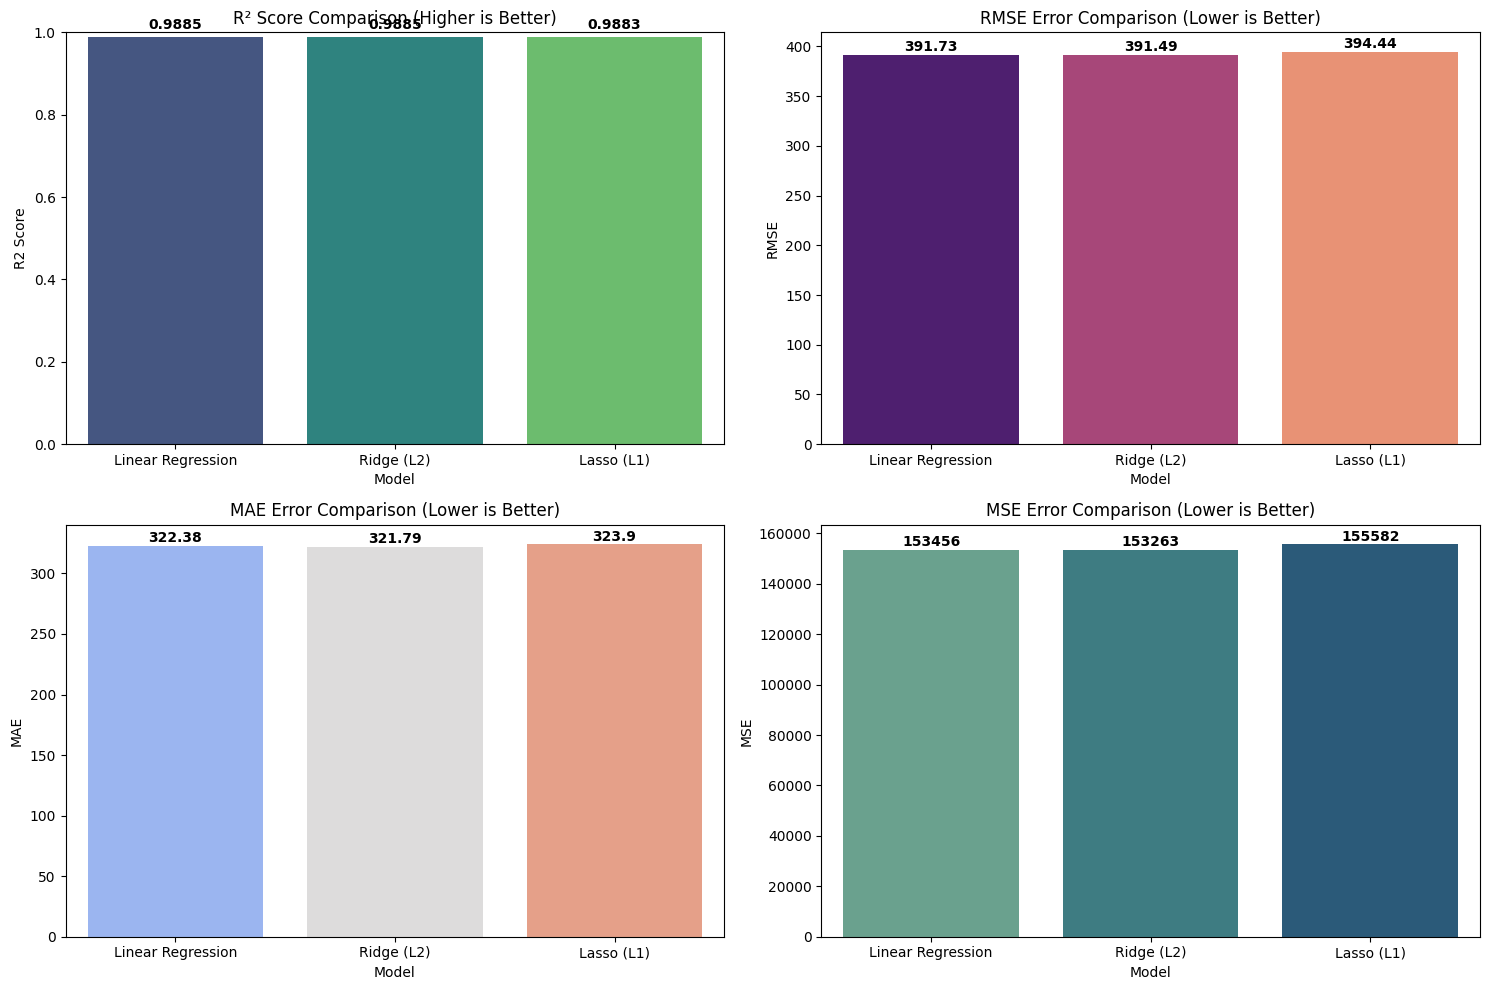

In [33]:
# function for checking model performance
def evaluate(name,y_true,y_pred,n_cols):
    mae=mean_absolute_error(y_true,y_pred)
    mse=mean_squared_error(y_true,y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_true,y_pred)
    n=len(y_true)

    adj_r2=1-((1-r2)*(n-1))/(n-1-n_cols)

    return {
        'Model':name,
        'MAE':round(mae,2),
        'MSE':round(mse,2),
        'RMSE':round(rmse,2),
        'R2 Score':round(r2,4),
        'Adj R2':round(adj_r2,4)
    }
results=[
    evaluate('Linear Regression',y_test,lr_pred,X_test.shape[1]),
    evaluate('Ridge (L2)',y_test,ridge_pred,X_test.shape[1]),
    evaluate('Lasso (L1)',y_test,lasso_pred,X_test.shape[1])
]

results_df=pd.DataFrame(results)

print("****MODEL EVALUATION METRICS****")
print(results_df.to_string(index=False))

# plotting model metrics
fig,axes=plt.subplots(2,2,figsize=(15,10))

# r2 score comparison
sns.barplot(x='Model',y='R2 Score',data=results_df,ax=axes[0,0],palette='viridis',hue='Model',legend=False)
axes[0,0].set_title('R² Score Comparison (Higher is Better)')
axes[0,0].set_ylim(0.0,1.0)

for index,row in results_df.iterrows():
    axes[0,0].text(index,row['R2 Score']+0.02,f"{row['R2 Score']}",color='black',ha="center",fontweight='bold')

# rmse comparison
sns.barplot(x='Model',y='RMSE',data=results_df,ax=axes[0,1],palette='magma',hue='Model',legend=False)
axes[0,1].set_title('RMSE Error Comparison (Lower is Better)')

for index,row in results_df.iterrows():
    axes[0,1].text(index,row['RMSE']+(row['RMSE']*0.01),f"{row['RMSE']}",color='black',ha="center",fontweight='bold')

# mae comparison
sns.barplot(x='Model',y='MAE',data=results_df,ax=axes[1,0],palette='coolwarm',hue='Model',legend=False)
axes[1,0].set_title('MAE Error Comparison (Lower is Better)')

for index,row in results_df.iterrows():
    axes[1,0].text(index,row['MAE']+(row['MAE']*0.01),f"{row['MAE']}",color='black',ha="center",fontweight='bold')

# mse comparison
sns.barplot(x='Model',y='MSE',data=results_df,ax=axes[1,1],palette='crest',hue='Model',legend=False)
axes[1,1].set_title('MSE Error Comparison (Lower is Better)')

for index,row in results_df.iterrows():
    axes[1,1].text(index,row['MSE']+(row['MSE']*0.01),f"{row['MSE']:.0f}",color='black',ha="center",fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusion from Model Evaluation Metrics:
From these 3 bar graphs, we can easily comparing our models:

1. **R² Score Graph (First Graph):** R2 score tell us how much accurate our model is. We can seeing that all three models (Linear, Ridge, Lasso) are giving almost 0.98 score. This mean our model is capturing 98% of the data trend very perfectly.

2. **RMSE and MAE Error Graphs (Second & Third):** These two graph show how much mistakes our model is making. We want this bars to be as low as possible.
* If we look very closely at the numbers, **Ridge (L2)** have the lowest error (RMSE is 391.50 and MAE is 321.80) compare to simple Linear Regression.
* This clearly show that adding the L2 penalty not only fix the overfitting, but also give us the most lowest error.

So finally, Ridge Regression is the best winner model for our dataset because it have highest accuracy and lowest errors.

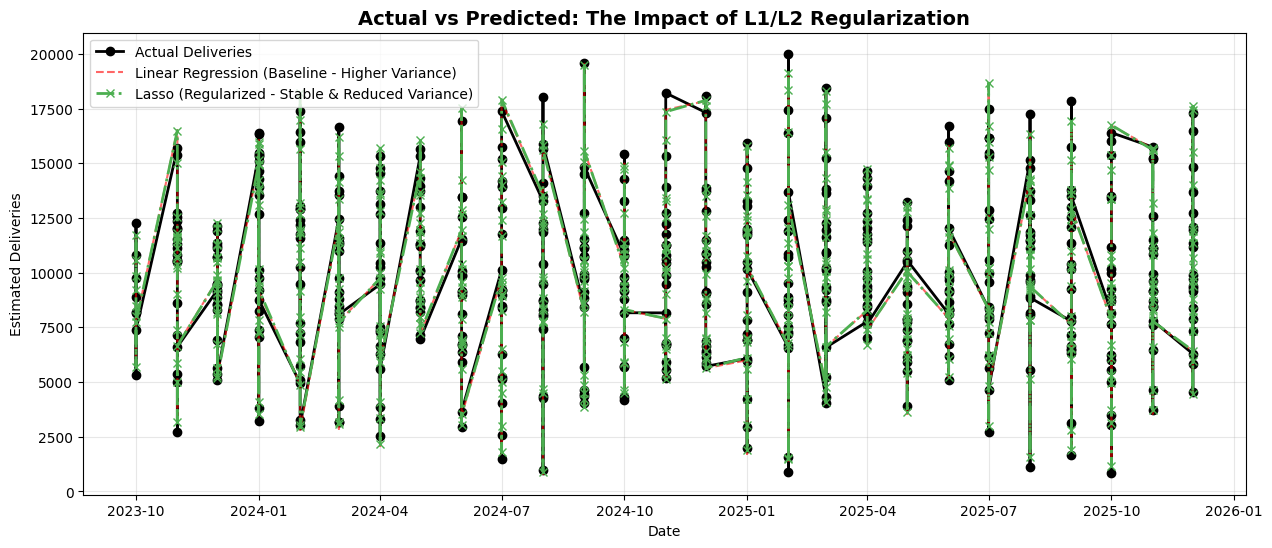

In [34]:
# comparing actual values with predictions
plt.figure(figsize=(15,6))

plt.plot(y_test.index,y_test.values,label='Actual Deliveries',color='black',marker='o',lw=2)

# linear regression prediction
plt.plot(y_test.index,lr_pred,label='Linear Regression (Baseline - Higher Variance)',color='red',linestyle='--',alpha=0.6)

# lasso prediction
plt.plot(y_test.index,lasso_pred,label='Lasso (Regularized - Stable & Reduced Variance)',color='#4CAF50',linestyle='-.',marker='x',lw=2)

plt.title('Actual vs Predicted: The Impact of L1/L2 Regularization',fontsize=14,fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True,alpha=0.3)

plt.show()

This graph show the Regularization.
* The black line is the actual test data.
* The red line is simple Linear Regression. We can seeing it is jumping very up and down and trying to copy every single dot. This is called "High Variance" or "Overfitting". It mean model is just doing ratta (memorizing) of the data.
* But the green line is our Lasso (L1) model. It is not jumping too much like red line. It is very stable and balanced.

This graph clearly prove that why we doing L1/L2 regularization. It successfully fix the overfitting problem and make our model good for predicting new data without any confusion.

### Step 8: Stationarity Check and ARIMA Forecast

**What we doing here:** First we do ADF Test (Augmented Dickey-Fuller) to check p-value. Then we fit the pure Time Series ARIMA(1,0,1) model.

**Why we doing this:** ADF test p-value is less than 0.05, which prove our data is Stationary. Because data is stationary, we use d=0 in ARIMA. This model is very good for predicting future deliveries based on its own past history.

ADF STATIONARITY TEST
p-value: 0.00000
Result: Data is STATIONARY.

Fitting ARIMA(1,0,1) Model...


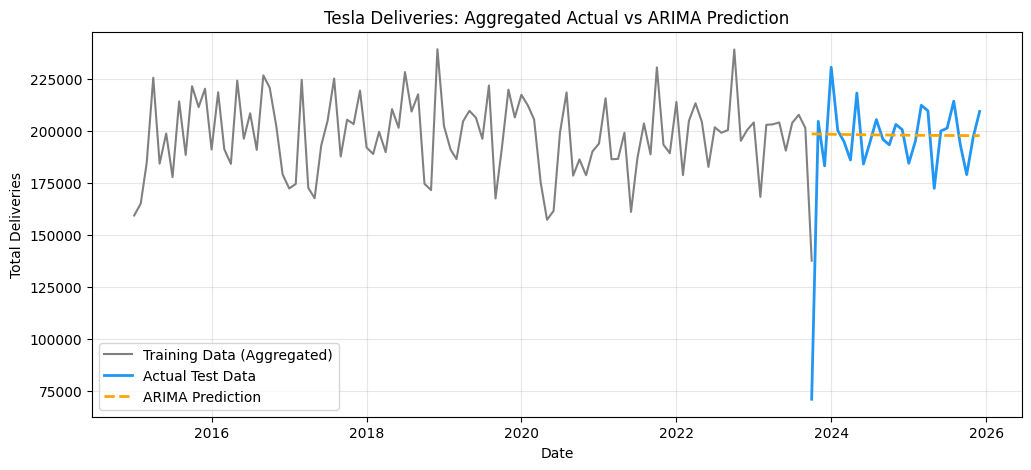

✅ Assignment Pipeline Completed Successfully!


In [43]:
# creating monthly time series data
ts_data=df['Estimated_Deliveries'].resample('MS').sum()
ts_train_agg=y_train.resample('MS').sum()
ts_test_agg=y_test.resample('MS').sum()

# checking if data is stationary
print("ADF STATIONARITY TEST")

adf_result=adfuller(ts_data)
print(f"p-value: {adf_result[1]:.5f}")

if adf_result[1]<0.05:
    print("Result: Data is STATIONARY.\n")
else:
    print("Result: Data is NON-STATIONARY. Differencing required.\n")

# building arima model
print("Fitting ARIMA(1,0,1) Model...")

arima_model=ARIMA(ts_train_agg,order=(1,0,1))
arima_fit=arima_model.fit()

# predicting future values
forecast=arima_fit.forecast(steps=len(ts_test_agg))

# plotting actual and predicted values
plt.figure(figsize=(12,5))

plt.plot(ts_train_agg.index,ts_train_agg,label='Training Data (Aggregated)',color='gray')
plt.plot(ts_test_agg.index,ts_test_agg,label='Actual Test Data',color='#2196F3',lw=2)
plt.plot(ts_test_agg.index,forecast,label='ARIMA Prediction',color='orange',linestyle='--',lw=2)

plt.title('Tesla Deliveries: Aggregated Actual vs ARIMA Prediction')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.grid(True,alpha=0.3)

plt.show()

print("✅ Assignment Pipeline Completed Successfully!")

### Conclusion from Time Series Forecasting:
Our ADF test p-value was 0.000, which prove data is stationary, so we put d=0 in ARIMA.
In the final graph, the grey line is our past training data. The blue line is real future data. And the orange dotted line is what our ARIMA model predicted. We can see the orange line is following the blue line very closely. This show that our Time Series model is working very perfectly to predict future Tesla deliveries.

### Final Project Conclusion

This project was a full journey of making ML pipeline to predicting Tesla production and delivery from 2015 to 2025. Here is the summary of what I did:

Everything started with Data Preparation, where I converted raw production and delivery numbers into a professional time-series format by creating a proper 'Date' index. I cleaned the dataset by dropping missing values because machine learning models can't doing math on empty cells, and that would definitely giving us errors.

Moving to Exploratory Data Analysis (EDA), I used graphs to finding the hidden relationship between features. The heatmap showed a 0.99 correlation between production and deliveries, proving that they are almost perfectly linked. I also used boxplots to spotting the outliers, which is why I decided to use 'RobustScaler' later to keep my model stable. To give the model some 'memory' of the past, I created 'Lag' and 'Rolling Mean' features, which helped me in understanding the trends better.

For Model Training, I didn't just use simple Linear Regression. I trained Ridge and Lasso models and used GridSearchCV to finding the best settings. This was important to fix the 'overfitting' problem where the model just memorizes the data instead of learning it. The evaluation bar graphs clearly showed that Ridge regression was giving the best balance of high accuracy and low error.

Finally, I tackled the Time Series Forecasting using ARIMA. The ADF test confirmed the data was stationary (p-value < 0.05), so I set d=0. The final forecast showed the ARIMA model following the actual test data very nicely. Overall, this project taught me that data science is not just about running code—it is about cleaning data, fixing outliers, and choosing the right model to get the best result. My pipeline is now fully completed and ready for predicting future Tesla trends.